In [ ]:
#Script developed by Isaac Sebenius
#Original script: https://github.com/isebenius/MIND
#Reference: Sebenius, I., Seidlitz, J., Warrier, V. et al. Robust Estimation of Cortical Similarity Networks from Brain MRI. Nat Neurosci 26, 1461–1471 (2023). https://doi.org/10.1038/s41593-023-01376-7

In [1]:
from scipy.spatial import cKDTree as KDTree
import numpy as np
import pandas as pd
from collections import defaultdict
import sys
import numpy as np
import os
import pandas as pd
from os.path import exists
from nibabel.freesurfer.io import read_morph_data, read_annot
from nibabel.freesurfer.mghformat import load
from collections import defaultdict
from MIND_helpers import calculate_mind_network, is_outlier
from get_vertex_df import get_vertex_df
from MIND import compute_MIND
import matplotlib.pyplot as plt

In [2]:
## Specify features to include in MIND calculation. The following abbreviations specifies the ?h.thickness, ?h.curv, ?h.volume, ?h.sulc, and ?h.area Freesurfer surface features.
features = ['CT','MC','Vol','SD','SA'] 

## Select which parcellation to use. This has been tested on Desikan Killiany (DK), HCP-Glasser, DK-308 and DK-318 parcellations.
parcellation = 'aparc' 

In [3]:
#Track HD 

base_directory = '/Users/charlie/Desktop/my_projects/neurotransmitter/github/data'

subject_names = [
    '000-000-001', '000-000-002'
]

for subject in subject_names:
    folder_path = os.path.join(base_directory, subject)
    mri_subdirectory = os.path.join(folder_path, 'mri/')
    annot_file_path = os.path.join(folder_path, 'label', 'rh.aparc.annot')

    # Check if the "mri" subdirectory and annot file exist for the current subject
    if os.path.exists(mri_subdirectory) and os.path.exists(annot_file_path):
        print(f"Processing subject: {subject}")

        # Specify the path to the surfer directory
        path_to_surf_dir = folder_path

        # Compute the MIND network for the current subject
        MIND = compute_MIND(path_to_surf_dir, features, parcellation)

        # Specify the path to save the CSV file for the current subject
        csv_file_path = os.path.join(folder_path, 'mri', 'mind.csv')
        MIND.to_csv(csv_file_path, index=True)
    else:
        print(f"Skipping subject: {subject} (No 'mri' subdirectory or annot file)")

print("Processing complete.")

Processing subject: 000-000-001
lh
Loading left hemisphere data:
/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/000-000-001/surf/lh.thickness
/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/000-000-001/surf/lh.curv
/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/000-000-001/surf/lh.volume
/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/000-000-001/surf/lh.sulc
/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/000-000-001/surf/lh.area
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
features used: 
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
Computing MIND...


KeyboardInterrupt: 

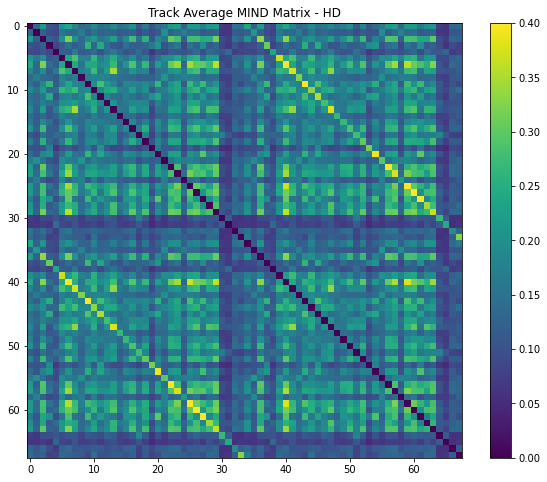

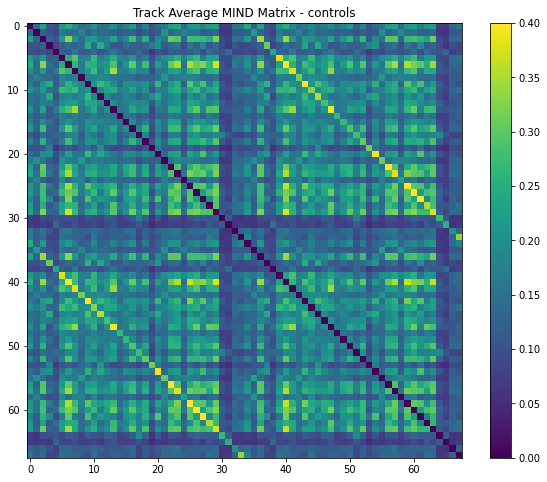

<Figure size 432x288 with 0 Axes>

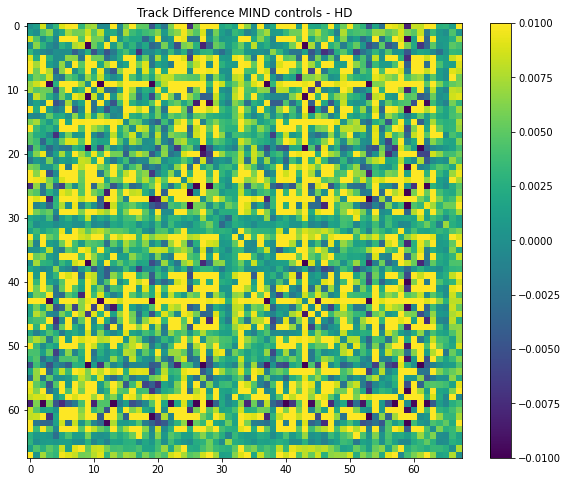

<Figure size 432x288 with 0 Axes>

In [153]:
# PLOT TRACK


data_dir = '/Users/charlie/Desktop/my_projects/neurotransmitter/imaging_metrics/thickness/track/carlos/'
total_mind_matrix = None


HD = [
     '001-849-234', '012-366-774', '015-955-315', '022-622-624', '045-416-487', '055-258-36X', '058-773-254',
     '076-516-247', '082-977-366', '097-360-545', '111-611-855', '135-074-011', '142-362-697', '148-282-432',
     '152-270-051', '167-674-345', '170-150-67X', '185-149-438', '194-580-124', '203-339-470', '222-456-485',
     '247-505-545', '252-965-812', '255-614-373', '257-482-956', '290-747-993', '293-870-143', '320-399-079',
     '334-173-08X', '341-438-293', '341-494-566', '357-863-029', '385-258-667', '402-592-63X', '409-361-689',
     '412-071-888', '419-540-733', '421-096-196', '450-440-376', '458-708-029', '468-117-398', '468-379-094',
     '477-657-055', '479-821-083', '511-596-898', '516-976-502', '519-841-602', '524-872-211', '530-492-039',
     '533-941-845', '535-845-735', '552-870-477', '560-216-908', '566-677-965', '568-115-448', '570-078-26X',
     '576-848-717', '589-274-610', '605-426-141', '606-181-467', '637-347-645', '644-036-541', '644-452-956',
     '646-397-768', '650-290-626', '658-092-030', '658-928-600', '665-180-986', '668-898-899', '671-115-078',
     '676-347-721', '677-054-536', '684-456-460', '720-696-084', '731-368-904', '737-785-88X', '743-991-478',
     '746-350-260', '746-450-951', '753-361-684', '753-414-02X', '756-009-357', '763-441-77X', '776-992-986',
     '779-728-803', '782-783-998', '790-072-700', '797-329-535', '807-805-94X', '829-403-224', '839-586-65X',
     '847-368-27X', '860-542-344', '871-190-645', '885-020-546', '898-719-681', '908-478-72X', '917-669-620',
     '919-209-439', '919-415-581', '936-254-810', '941-766-342', '946-198-993', '970-303-450', '975-970-37X',
     '977-924-56X', '978-504-512', '991-700-334', '995-088-226'
]


for subject_name in HD:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_HD = total_mind_matrix / len(HD)
plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_HD, vmax=0.4)
plt.colorbar()
plt.title('Track Average MIND Matrix - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/track/figures/mind_average.eps')
plt.show()




total_mind_matrix = None
average_mind_matrix_controls = None


controls = [
    '002-814-880', '014-636-60X', '020-527-191', '026-038-129', '028-502-628', '029-806-281', '048-618-106',
    '066-092-953', '083-006-668', '084-647-431', '094-406-044', '113-434-720', '121-366-443', '122-786-400',
    '127-352-856', '156-454-974', '161-384-787', '178-439-836', '180-022-928', '184-430-539', '194-338-142',
    '203-312-224', '215-988-769', '229-424-853', '260-725-083', '261-556-323', '265-897-681', '287-905-458',
    '288-066-870', '298-379-632', '313-680-688', '323-287-434', '333-956-667', '334-769-503', '340-215-444',
    '353-346-828', '355-890-885', '380-665-495', '391-258-497', '393-021-155', '403-534-287', '410-568-432',
    '423-065-025', '423-187-239', '434-114-445', '434-855-782', '441-374-525', '450-251-265', '466-432-484',
    '497-716-01X', '499-131-314', '499-922-022', '502-390-85X', '503-434-462', '505-250-482', '505-852-581',
    '508-171-175', '510-498-223', '511-102-082', '521-466-038', '530-326-672', '554-346-509', '563-329-576',
    '566-346-239', '573-330-25X', '577-436-951', '584-018-112', '640-127-584', '674-076-919', '679-528-876',
    '680-588-411', '697-397-624', '709-053-559', '711-693-915', '719-200-210', '726-127-086', '732-653-023',
    '741-254-703', '748-377-562', '759-571-458', '766-360-511', '780-339-496', '781-352-297', '801-679-448',
    '809-554-820', '815-141-274', '823-955-340', '831-159-453', '833-038-920', '834-082-962', '839-554-46X',
    '842-725-810', '846-447-251', '856-037-521', '864-773-074', '867-249-739', '869-072-209', '871-295-436',
    '895-670-492', '896-972-32X', '897-826-627', '898-585-830', '917-306-576', '917-537-476', '917-951-185',
    '925-743-230', '933-580-879', '934-026-854', '955-331-485', '977-891-134', '988-505-623'
]







for subject_name in controls:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_controls = total_mind_matrix / len(controls)

plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_controls, vmax=0.4)
plt.colorbar()
plt.title('Track Average MIND Matrix - controls')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/track/figures/mind_controls.eps')
plt.show()




difference_matrix = average_mind_matrix_controls - average_mind_matrix_HD

plt.figure(figsize=((10,8)))
plt.imshow(difference_matrix,vmin=-0.01, vmax=0.01)
plt.colorbar()
plt.title('Track Difference MIND controls - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/track/figures/mind_difference.eps')
plt.show()


In [151]:
print(difference_matrix)

                            lh_bankssts  lh_caudalanteriorcingulate  \
lh_bankssts                    0.000000                    0.001145   
lh_caudalanteriorcingulate     0.001145                    0.000000   
lh_caudalmiddlefrontal         0.008697                    0.004551   
lh_cuneus                      0.000052                    0.006436   
lh_entorhinal                  0.003131                    0.000420   
...                                 ...                         ...   
rh_supramarginal               0.011696                    0.003545   
rh_frontalpole                 0.002689                    0.000758   
rh_temporalpole                0.002971                   -0.000010   
rh_transversetemporal          0.001307                    0.004433   
rh_insula                      0.012486                    0.000419   

                            lh_caudalmiddlefrontal  lh_cuneus  lh_entorhinal  \
lh_bankssts                               0.008697   0.000052      

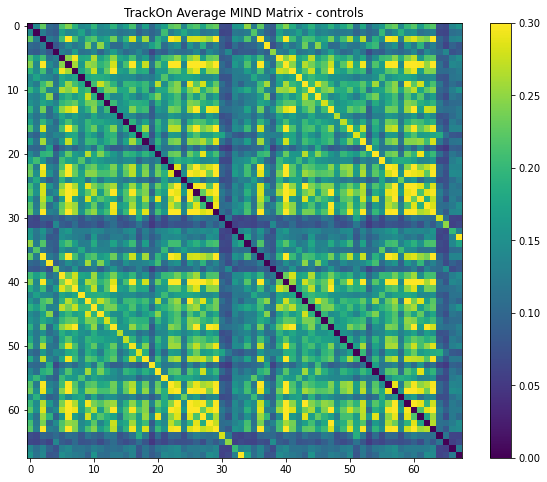

<Figure size 432x288 with 0 Axes>

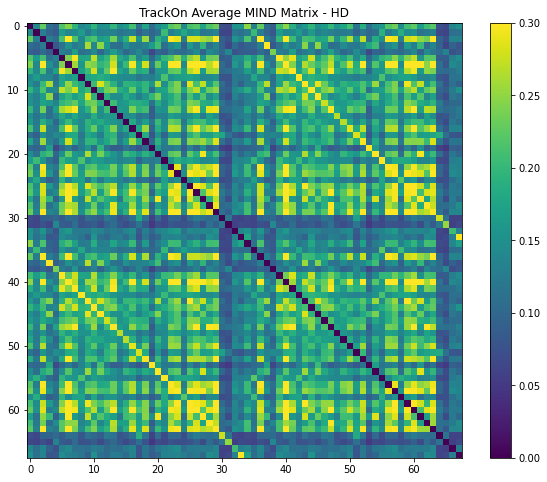

<Figure size 432x288 with 0 Axes>

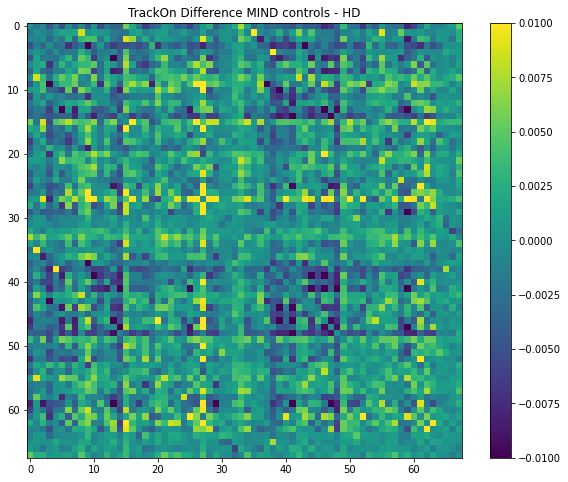

<Figure size 432x288 with 0 Axes>

In [152]:
# PLOT TRACK-ON


data_dir = '/Users/charlie/Desktop/my_projects/neurotransmitter/imaging_metrics/thickness/trackon/carlos/'
total_mind_matrix = None
average_mind_matrix = None
average_mind_matrix_controls=None
average_mind_matrix_HD= None

controls = [
    '002-814-880', '014-636-60X', '028-502-628', '031-225-835', '060-443-961', '060-637-795', '066-092-953',
    '076-328-583', '083-006-668', '084-647-431', '094-406-044', '104-661-605', '112-279-092', '121-366-443',
    '127-352-856', '153-475-212', '158-312-991', '176-035-033', '178-439-836', '184-430-539', '185-844-646',
    '194-338-142', '203-312-224', '215-988-769', '229-424-853', '265-897-681', '287-905-458', '288-066-870',
    '323-287-434', '325-138-528', '334-769-503', '355-066-390', '355-890-885', '357-066-955', '410-568-432',
    '423-065-025', '434-114-445', '450-771-084', '499-131-314', '502-390-85X', '503-434-462', '505-250-482',
    '511-102-082', '521-466-038', '541-359-481', '573-330-25X', '577-436-951', '609-527-209', '626-471-168',
    '640-127-584', '679-528-876', '701-804-865', '709-053-559', '719-200-210', '726-127-086', '726-245-84X',
    '735-042-927', '743-429-012', '748-377-562', '781-352-297', '784-395-492', '809-554-820', '815-141-274',
    '831-159-453', '833-038-920', '842-725-810', '846-447-251', '859-846-898', '864-773-074', '869-072-209',
    '871-295-436', '876-904-542', '878-885-813', '880-536-555', '895-670-492', '896-972-32X', '897-826-627',
    '898-585-830', '917-306-576', '917-951-185', '925-743-230', '933-580-879', '934-026-854', '944-397-199',
    '964-290-137', '973-738-963', '982-721-728', '984-093-001', '988-505-623'
]




for subject_name in controls:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_controls = total_mind_matrix / len(controls)

plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_controls, vmax=0.3)
plt.colorbar()
plt.title('TrackOn Average MIND Matrix - controls')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/trackon/figures/mind_controls.eps')
plt.show()





# del (total_mind_matrix)
# del (average_mind_matrix)


average_mind_matrix_HD= None
total_mind_matrix = None
average_mind_matrix = None

HD = [
    '034-032-275', '048-157-730', '049-137-321', '068-044-003', '085-951-323', '102-334-277', '106-115-590',
    '108-668-102', '111-303-380', '116-963-426', '118-834-031', '121-302-070', '122-413-846', '142-620-813',
    '146-484-385', '147-577-839', '151-233-979', '160-084-210', '173-370-126', '180-118-022', '198-909-663',
    '209-569-713', '228-684-524', '242-201-054', '245-231-00X', '245-692-548', '249-903-245', '250-506-098',
    '266-556-423', '286-813-423', '289-351-801', '326-821-046', '349-964-982', '375-069-127', '393-552-152',
    '406-054-927', '407-847-105', '419-686-535', '436-813-077', '444-465-738', '445-596-181', '501-296-799',
    '511-523-238', '511-926-591', '529-746-00X', '543-829-595', '544-679-981', '559-531-06X', '564-735-156',
    '574-798-176', '600-785-158', '614-993-411', '616-488-557', '621-782-311', '629-891-106', '633-319-246',
    '642-962-953', '653-976-46X', '680-987-257', '695-277-31X', '714-279-727', '726-206-594', '755-907-833',
    '756-129-837', '806-385-393', '825-986-523', '826-350-503', '828-162-23X', '830-135-905', '830-478-042',
    '841-795-617', '849-945-816', '874-151-633', '881-028-481', '897-765-327', '906-624-638', '908-925-145',
    '909-523-690', '925-554-571', '929-174-584', '932-487-54X', '945-595-159', '961-041-497', '969-709-824',
    '993-739-866'
]



for subject_name in HD:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_HD = total_mind_matrix / len(HD)
plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_HD, vmax=0.3)
plt.colorbar()
plt.title('TrackOn Average MIND Matrix - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/trackon/figures/mind_HD.eps')
plt.show()






difference_matrix = average_mind_matrix_controls - average_mind_matrix_HD
plt.figure(figsize=((10,8)))
plt.imshow(difference_matrix,vmin=-0.01, vmax=0.01)
plt.colorbar()
plt.title('TrackOn Difference MIND controls - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/trackon/figures/mind_difference.eps')
plt.show()




MIND.csv not found for subject 811-619-595


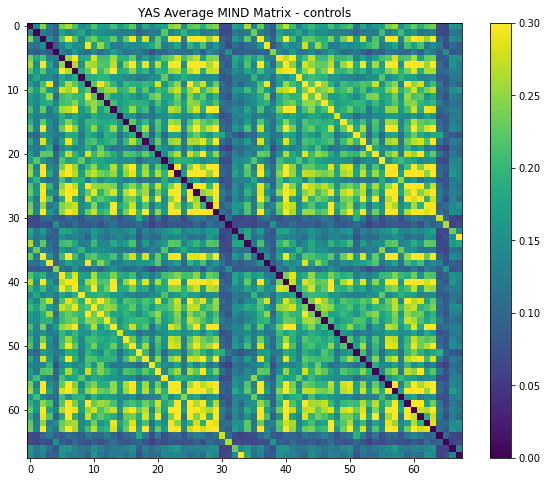

MIND.csv not found for subject 184-294-808
MIND.csv not found for subject 254-060-654
MIND.csv not found for subject 439-957-225
MIND.csv not found for subject 639-111-437


<Figure size 432x288 with 0 Axes>

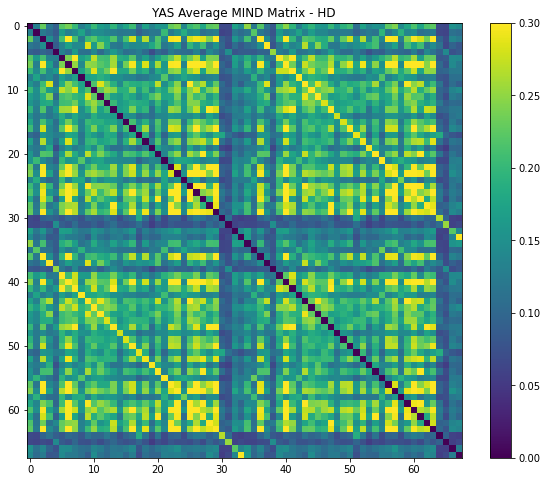

<Figure size 432x288 with 0 Axes>

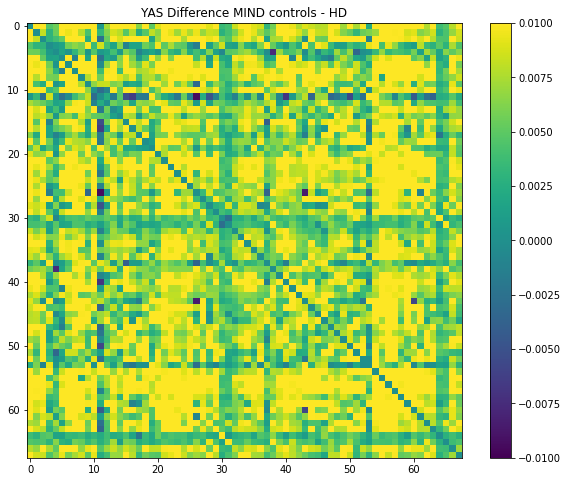

<Figure size 432x288 with 0 Axes>

In [154]:
# PLOT YAS


data_dir = '/Users/charlie/Desktop/my_projects/neurotransmitter/imaging_metrics/thickness/yas/data/fsv7/'
total_mind_matrix = None
average_mind_matrix = None
average_mind_matrix_controls=None
average_mind_matrix_HD= None

controls = [
    '025-412-104', '102-058-850', '127-327-696', '133-029-505', '136-450-655', '175-476-555', '176-167-280',
    '189-229-038', '194-965-440', '236-860-986', '244-189-693', '270-592-197', '300-810-352', '347-345-53X',
    '360-832-809', '374-460-945', '401-848-314', '421-642-706', '425-324-672', '436-350-106', '439-480-350',
    '446-836-900', '447-789-503', '469-831-862', '471-931-706', '495-215-487', '497-629-832', '532-875-164',
    '535-604-129', '553-404-347', '588-850-544', '599-783-584', '605-637-672', '623-412-047', '639-016-52X',
    '659-057-776', '661-959-844', '666-039-878', '682-004-613', '683-560-470', '693-077-089', '697-764-839',
    '703-937-818', '712-823-482', '713-787-847', '721-374-047', '743-352-167', '795-737-207', '811-619-595',
    '815-212-020', '830-420-128', '837-534-725', '841-587-922', '846-551-684', '848-381-387', '869-822-454',
    '872-447-861', '885-510-137', '928-510-320', '969-530-134', '983-545-667'
]





for subject_name in controls:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_controls = total_mind_matrix / len(controls)

plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_controls, vmax=0.3)
plt.colorbar()
plt.title('YAS Average MIND Matrix - controls')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/yas/figures/mind_controls.eps')
plt.show()






average_mind_matrix_HD= None
total_mind_matrix = None
average_mind_matrix = None

HD = [
    '011-981-469', '051-234-165', '080-254-263', '095-240-173', '095-862-435', '096-798-996', '099-194-595',
    '103-252-88X', '126-869-99X', '167-617-547', '183-430-162', '184-294-808', '221-489-856', '243-468-220',
    '252-088-078', '254-060-654', '267-642-099', '275-591-081', '293-127-289', '347-993-84X', '359-854-406',
    '411-981-10X', '439-957-225', '451-891-827', '461-717-159', '475-553-428', '497-879-597', '526-254-466',
    '532-373-521', '532-377-391', '535-031-149', '557-664-424', '575-462-659', '617-353-683', '631-052-766',
    '639-111-437', '643-631-43X', '652-981-845', '653-799-443', '675-248-916', '695-066-942', '751-806-527',
    '773-175-527', '777-809-20X', '787-142-882', '829-885-557', '843-897-211', '844-605-005', '871-442-562',
    '886-679-994', '888-778-279', '901-484-641', '920-784-159', '928-234-815', '937-242-362', '944-631-182',
    '949-404-41X', '951-575-823', '966-803-29X', '974-584-468', '981-574-03X'
]




for subject_name in HD:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_HD = total_mind_matrix / len(HD)
plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_HD, vmax=0.3)
plt.colorbar()
plt.title('YAS Average MIND Matrix - HD')
plt.show()

plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/yas/figures/mind_HD.eps')




difference_matrix = average_mind_matrix_controls - average_mind_matrix_HD

plt.figure(figsize=((10,8)))
plt.imshow(difference_matrix,vmin=-0.01, vmax=0.01)
plt.colorbar()
plt.title('YAS Difference MIND controls - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/yas/figures/mind_difference.eps')
plt.show()




In [1]:
###########TRY


data_dir = '/Users/charlie/Desktop/my_projects/neurotransmitter/imaging_metrics/thickness/track/carlos/'
total_mind_matrix = None


HD = [
     '001-849-234', '012-366-774', '015-955-315', '022-622-624', '045-416-487', '055-258-36X', '058-773-254',
     '076-516-247', '082-977-366', '097-360-545', '111-611-855', '135-074-011', '142-362-697', '148-282-432',
     '152-270-051', '167-674-345', '170-150-67X', '185-149-438', '194-580-124', '203-339-470', '222-456-485',
     '247-505-545', '252-965-812', '255-614-373', '257-482-956', '290-747-993', '293-870-143', '320-399-079',
     '334-173-08X', '341-438-293', '341-494-566', '357-863-029', '385-258-667', '402-592-63X', '409-361-689',
     '412-071-888', '419-540-733', '421-096-196', '450-440-376', '458-708-029', '468-117-398', '468-379-094',
     '477-657-055', '479-821-083', '511-596-898', '516-976-502', '519-841-602', '524-872-211', '530-492-039',
     '533-941-845', '535-845-735', '552-870-477', '560-216-908', '566-677-965', '568-115-448', '570-078-26X',
     '576-848-717', '589-274-610', '605-426-141', '606-181-467', '637-347-645', '644-036-541', '644-452-956',
     '646-397-768', '650-290-626', '658-092-030', '658-928-600', '665-180-986', '668-898-899', '671-115-078',
     '676-347-721', '677-054-536', '684-456-460', '720-696-084', '731-368-904', '737-785-88X', '743-991-478',
     '746-350-260', '746-450-951', '753-361-684', '753-414-02X', '756-009-357', '763-441-77X', '776-992-986',
     '779-728-803', '782-783-998', '790-072-700', '797-329-535', '807-805-94X', '829-403-224', '839-586-65X',
     '847-368-27X', '860-542-344', '871-190-645', '885-020-546', '898-719-681', '908-478-72X', '917-669-620',
     '919-209-439', '919-415-581', '936-254-810', '941-766-342', '946-198-993', '970-303-450', '975-970-37X',
     '977-924-56X', '978-504-512', '991-700-334', '995-088-226'
]


for subject_name in HD:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_HD = total_mind_matrix / len(HD)
plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_HD, vmax=0.4)
plt.colorbar()
plt.title('Track Average MIND Matrix - HD')
plt.show()




total_mind_matrix = None
average_mind_matrix_controls = None


controls = [
    '002-814-880', '014-636-60X', '020-527-191', '026-038-129', '028-502-628', '029-806-281', '048-618-106',
    '066-092-953', '083-006-668', '084-647-431', '094-406-044', '113-434-720', '121-366-443', '122-786-400',
    '127-352-856', '156-454-974', '161-384-787', '178-439-836', '180-022-928', '184-430-539', '194-338-142',
    '203-312-224', '215-988-769', '229-424-853', '260-725-083', '261-556-323', '265-897-681', '287-905-458',
    '288-066-870', '298-379-632', '313-680-688', '323-287-434', '333-956-667', '334-769-503', '340-215-444',
    '353-346-828', '355-890-885', '380-665-495', '391-258-497', '393-021-155', '403-534-287', '410-568-432',
    '423-065-025', '423-187-239', '434-114-445', '434-855-782', '441-374-525', '450-251-265', '466-432-484',
    '497-716-01X', '499-131-314', '499-922-022', '502-390-85X', '503-434-462', '505-250-482', '505-852-581',
    '508-171-175', '510-498-223', '511-102-082', '521-466-038', '530-326-672', '554-346-509', '563-329-576',
    '566-346-239', '573-330-25X', '577-436-951', '584-018-112', '640-127-584', '674-076-919', '679-528-876',
    '680-588-411', '697-397-624', '709-053-559', '711-693-915', '719-200-210', '726-127-086', '732-653-023',
    '741-254-703', '748-377-562', '759-571-458', '766-360-511', '780-339-496', '781-352-297', '801-679-448',
    '809-554-820', '815-141-274', '823-955-340', '831-159-453', '833-038-920', '834-082-962', '839-554-46X',
    '842-725-810', '846-447-251', '856-037-521', '864-773-074', '867-249-739', '869-072-209', '871-295-436',
    '895-670-492', '896-972-32X', '897-826-627', '898-585-830', '917-306-576', '917-537-476', '917-951-185',
    '925-743-230', '933-580-879', '934-026-854', '955-331-485', '977-891-134', '988-505-623'
]







for subject_name in controls:
    subject_dir = os.path.join(data_dir, subject_name, 'mri')
    mind_csv_path = os.path.join(subject_dir, 'mind.csv')
    
# Check if the MIND.csv file exists for the subject
    if os.path.exists(mind_csv_path):
        mind_df = pd.read_csv(mind_csv_path, index_col=0)
        
        if total_mind_matrix is None:
            total_mind_matrix = mind_df
        else:
            total_mind_matrix += mind_df
    else:
        print(f'MIND.csv not found for subject {subject_name}')
        
average_mind_matrix_controls = total_mind_matrix / len(controls)

plt.figure(figsize=((10,8)))
plt.imshow(average_mind_matrix_controls, vmax=0.4)
plt.colorbar()
plt.title('Track Average MIND Matrix - controls')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/track/figures/mind_controls.eps')

plt.show()



difference_matrix = average_mind_matrix_controls - average_mind_matrix_HD

plt.figure(figsize=((10,8)))
plt.imshow(difference_matrix,vmin=-0.01, vmax=0.01)
plt.colorbar()
plt.title('Track Difference MIND controls - HD')
plt.savefig('/Users/charlie/Desktop/my_projects/neurotransmitter/mind/results/track/figures/mind_difference.eps')
plt.show()


NameError: name 'os' is not defined

In [161]:
print(average_mind_matrix_HD)

                            lh_bankssts  lh_caudalanteriorcingulate  \
lh_bankssts                    0.000000                    0.135060   
lh_caudalanteriorcingulate     0.135060                    0.000000   
lh_caudalmiddlefrontal         0.221040                    0.124243   
lh_cuneus                      0.107049                    0.094109   
lh_entorhinal                  0.092023                    0.085345   
...                                 ...                         ...   
rh_supramarginal               0.212933                    0.126406   
rh_frontalpole                 0.071996                    0.064060   
rh_temporalpole                0.062217                    0.060671   
rh_transversetemporal          0.134772                    0.106191   
rh_insula                      0.141028                    0.109636   

                            lh_caudalmiddlefrontal  lh_cuneus  lh_entorhinal  \
lh_bankssts                               0.221040   0.107049      

In [162]:
print(average_mind_matrix_controls)

                            lh_bankssts  lh_caudalanteriorcingulate  \
lh_bankssts                    0.000000                    0.136205   
lh_caudalanteriorcingulate     0.136205                    0.000000   
lh_caudalmiddlefrontal         0.229736                    0.128794   
lh_cuneus                      0.107101                    0.100545   
lh_entorhinal                  0.095154                    0.085765   
...                                 ...                         ...   
rh_supramarginal               0.224629                    0.129951   
rh_frontalpole                 0.074684                    0.064819   
rh_temporalpole                0.065187                    0.060661   
rh_transversetemporal          0.136079                    0.110624   
rh_insula                      0.153513                    0.110055   

                            lh_caudalmiddlefrontal  lh_cuneus  lh_entorhinal  \
lh_bankssts                               0.229736   0.107101      